In [2]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/ncdlmzor/EstadisticaVerano2026/refs/heads/main/StudentPerformance/Student_Performance.csv")

df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


Establecemos las horas de estudio (Hours_Studied) como variable dependiente y el indice de desempeño ("Performance_Index") con la variable dependiente. Esto es porque la hipotesis inicial es que cambios en las horas de estudio puede cambiar cambios en el indice de desempeño, sin embargo cambios en los indices de desempeño no causa cambios en las horas de estudio.

In [3]:
X = df["Hours_Studied"]       # Variable independiente
Y = df["Performance_Index"]     # Variable dependiente

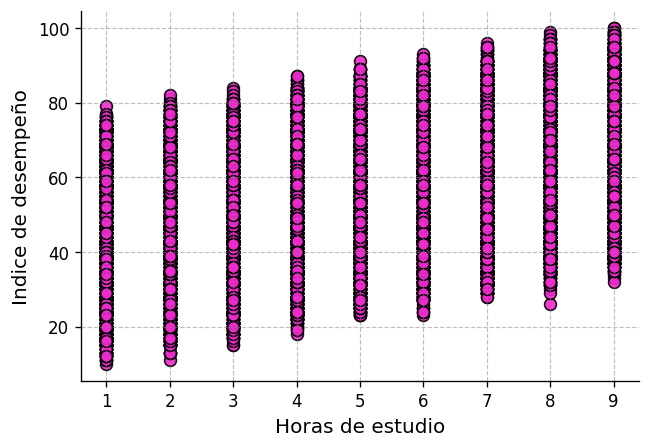

In [6]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Horas de estudio', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Indice de desempeño', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

La grafica de dispercion muestra una clara tendencia lineal. Se puede observar que conforme aumentan las horas de estudio ($X$) aumneta el indice de desempeño ($Y$). Con lo que se espera un coeficiente de correlacion positiva y parece cumplirse el supuesto de linealidad.

In [5]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlaciòn: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlaciòn:  0.3737
valor_p:  0.0000


El coeficiente de correlación $r=0.3737$ indica una correlación lineal débil, sin embargo, la prueba de hipótesis indica que a pesar de haber una rlación débil si existe correlación.

In [11]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [8]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  13.97%


Una vez ajustado el modelo de regresión lineal se obtiene un coeficiente de determinación de $R^2=0.1397$. Entonces teniendo las horas de estudio y el modelo ajustado, solo podemos justificar la variabilidad en las calificaciones en un 13.97%, lo que es muy bajo para poder realizar predicciones precisas.

In [9]:
modelo.params

,0
const,41.379175
Hours_Studied,2.773063


La ecuación de la recta es:

$$
\hat{y}=41.379175+2.773063X
$$

Este modelo estima que la calificación base ($X=0$) es de aproximadamente $41.38$. Lo que significa que si un estudiante no estudio, se espera que obtenga un índice de desempeño con ese valor. Mientras que una pendiente de 2.77, indica que por cada hora estudiada se espera un aumento en la calificación de aproximadamente 2.77.

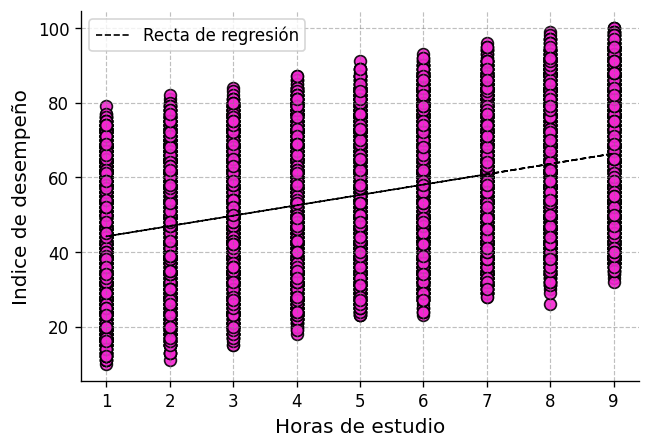

In [10]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Horas de estudio', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Indice de desempeño', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

La recta de regresión ajusta obtenida es muy consistente con las observaciones. Se esperaba una relación positiva. Sin embargo se observa una gran dispersión en los datos lo que causa que el coeficiente de determinación sea tan bajo.

In [12]:
modelo.conf_int(alpha=0.05)

,0,1
const,40.620341,42.138008
Hours_Studied,2.638143,2.907983


La intersección tiene un intervalo de confianza del 95% de $(48.62,42.14)$. Esto significa que se tiene un nivel de confianza del 95% de que  la calificación esperada para el estudiante que no estudio esta entre estpos valores. Por otra parte, según el intervalo de confianza de la pendiente, se espera que un estudiante gane entre 2.64 y de 2.91 puntops en su indice de desempeño por cada hora de estudio, Esto con una confianza del 95%.

In [13]:
residuales = modelo.resid

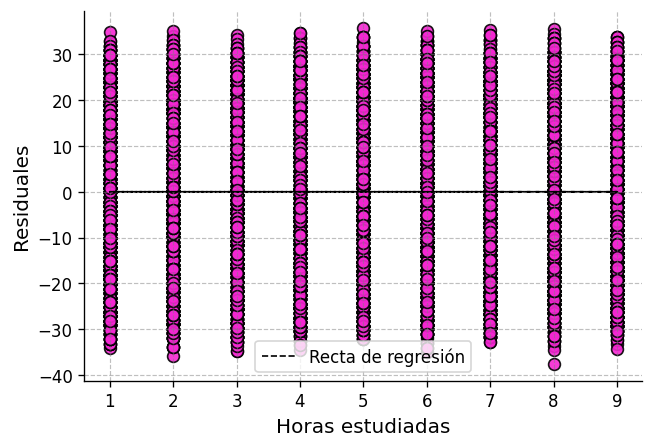

In [24]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Horas estudiadas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Indice de desempeño', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Los residuales parecen reforzar la ide de que los datos siguen una tendencia lineal. Los puntos pare3cen tener un color mas intenso cercano a la recta y más difuminados alejados de ellas, por lo que también podrían cumplir con una distribución normal. Además los datos parecen cumplir cavalmente con la homoscedasticidad. Sin embargo, pese a lo que se observa, se realizaran las pruebas estadísticas.

valor-p (Shapiro) = 2.3269507843403982e-45


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


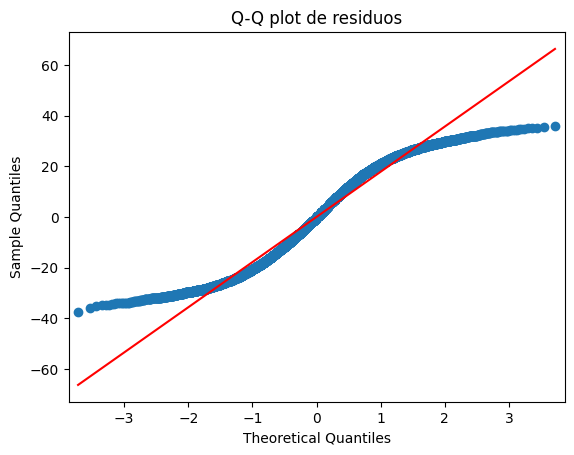

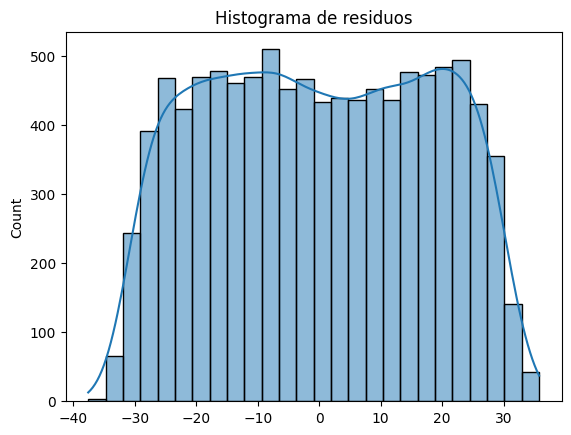

In [15]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro es el más confiable
# n >= 30, histograma o Q-Q plot
# test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Segun el grafico de cuantil_cuantil y el histograma, los residuales parecen cumplir con una distribución uniforme y no una distribución normal.

In [16]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.9742



Pero la suposición de homescedasticidad si se ve reforzada por la prueba de Breusch-Pagan.

In [17]:
# mínimo ausencias: 11
# máximo ausencias: 40

# interpolar, valores de x entre 11 y 40

# interpolar 1
y_25 = modelo.predict([1, 25])
y_32 = modelo.predict([1, 32])

print(f"Para x = 25, y =  {y_25[0]: 0.4f}")
print(f"Para x = 32, y =  {y_32[0]: 0.4f}")

Para x = 25, y =   110.7057
Para x = 32, y =   130.1172


In [18]:
df["hora_de_estudio_predicha"] = y_calculada.round()
df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index,hora_de_estudio_predicha
0,7,99,Yes,9,1,91.0,61.0
1,4,82,No,4,2,65.0,52.0
2,8,51,Yes,7,2,45.0,64.0
3,5,52,Yes,5,2,36.0,55.0
4,7,75,No,8,5,66.0,61.0
...,...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0,44.0
9996,7,64,Yes,8,5,58.0,61.0
9997,6,83,Yes,8,5,74.0,58.0
9998,9,97,Yes,7,0,95.0,66.0


In [19]:
# mínimo ausencias: 11
# máximo ausencias: 40

# Extrapolar, valores de x que no estén entre 11 y 40

y_10 = modelo.predict([[1, 10]])

print(f"Para x = 10, y =  {y_10[0]: 0.4f}")

Para x = 10, y =   69.1098


In [23]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Performance_Index ~ Hours_Studied',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Hours_Studied,1.0,5.155178e+05,515517.816522,1623.181225,0.0
Residual,9998.0,3.175337e+06,317.597203,NaN,NaN
